In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Sparkov/fraudTrain.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [5]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [6]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [7]:
df = df[['trans_date_trans_time','category','amt','zip','city_pop', 'dob','is_fraud' ]]

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 7 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   category               1296675 non-null  object 
 2   amt                    1296675 non-null  float64
 3   zip                    1296675 non-null  int64  
 4   city_pop               1296675 non-null  int64  
 5   dob                    1296675 non-null  object 
 6   is_fraud               1296675 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 69.3+ MB


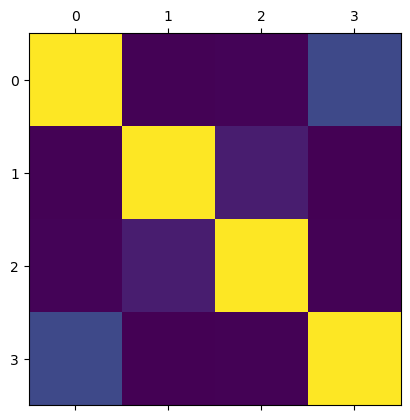

In [9]:
import matplotlib.pyplot as plt

plt.matshow(df.corr())
plt.show()

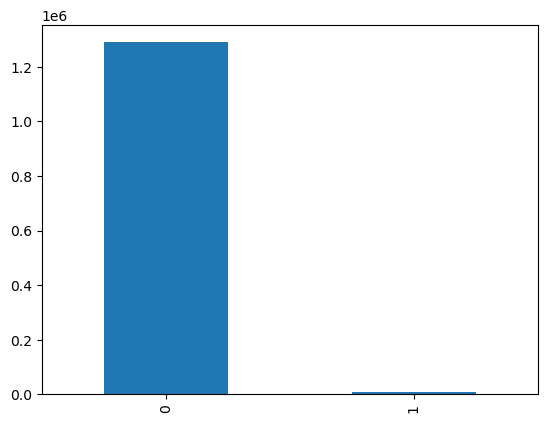

In [10]:
df.is_fraud.value_counts().plot(kind='bar');

In [11]:
df.head()

,trans_date_trans_time,category,amt,zip,city_pop,dob,is_fraud
0,2019-01-01 00:00:18,misc_net,4.97,28654,3495,1988-03-09,0
1,2019-01-01 00:00:44,grocery_pos,107.23,99160,149,1978-06-21,0
2,2019-01-01 00:00:51,entertainment,220.11,83252,4154,1962-01-19,0
3,2019-01-01 00:01:16,gas_transport,45.00,59632,1939,1967-01-12,0
4,2019-01-01 00:03:06,misc_pos,41.96,24433,99,1986-03-28,0


In [12]:
df['category'].value_counts()

gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: category, dtype: int64

In [13]:
df['trans_date_trans_time_1'] = pd.to_datetime(df['trans_date_trans_time'])

In [14]:
df['dob_1'] = pd.to_datetime(df['dob'])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   trans_date_trans_time    1296675 non-null  object        
 1   category                 1296675 non-null  object        
 2   amt                      1296675 non-null  float64       
 3   zip                      1296675 non-null  int64         
 4   city_pop                 1296675 non-null  int64         
 5   dob                      1296675 non-null  object        
 6   is_fraud                 1296675 non-null  int64         
 7   trans_date_trans_time_1  1296675 non-null  datetime64[ns]
 8   dob_1                    1296675 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(3), object(3)
memory usage: 89.0+ MB


In [16]:
del df['trans_date_trans_time']
del df['dob']

In [17]:
df.columns

Index(['category', 'amt', 'zip', 'city_pop', 'is_fraud',
       'trans_date_trans_time_1', 'dob_1'],
      dtype='object')

In [18]:
df['trans_year'] = pd.DatetimeIndex(df['trans_date_trans_time_1']).year
df['trans_month'] = pd.DatetimeIndex(df['trans_date_trans_time_1']).month
df['trans_day'] = pd.DatetimeIndex(df['trans_date_trans_time_1']).day

In [19]:
df['dob_year'] = pd.DatetimeIndex(df['dob_1']).year
df['dob_month'] = pd.DatetimeIndex(df['dob_1']).month
df['dob_day'] = pd.DatetimeIndex(df['dob_1']).day

In [20]:
df.head()

,category,amt,zip,city_pop,is_fraud,trans_date_trans_time_1,dob_1,trans_year,trans_month,trans_day,dob_year,dob_month,dob_day
0,misc_net,4.97,28654,3495,0,2019-01-01 00:00:18,1988-03-09,2019,1,1,1988,3,9
1,grocery_pos,107.23,99160,149,0,2019-01-01 00:00:44,1978-06-21,2019,1,1,1978,6,21
2,entertainment,220.11,83252,4154,0,2019-01-01 00:00:51,1962-01-19,2019,1,1,1962,1,19
3,gas_transport,45.00,59632,1939,0,2019-01-01 00:01:16,1967-01-12,2019,1,1,1967,1,12
4,misc_pos,41.96,24433,99,0,2019-01-01 00:03:06,1986-03-28,2019,1,1,1986,3,28


In [21]:
del df['trans_date_trans_time_1']
del df['dob_1']

In [22]:
df.columns

Index(['category', 'amt', 'zip', 'city_pop', 'is_fraud', 'trans_year',
       'trans_month', 'trans_day', 'dob_year', 'dob_month', 'dob_day'],
      dtype='object')

In [24]:
df = df[['trans_year','trans_month', 'trans_day','dob_year', 'dob_month',
       'dob_day','category', 'amt', 'zip', 'city_pop', 'is_fraud']]

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   trans_year   1296675 non-null  int64  
 1   trans_month  1296675 non-null  int64  
 2   trans_day    1296675 non-null  int64  
 3   dob_year     1296675 non-null  int64  
 4   dob_month    1296675 non-null  int64  
 5   dob_day      1296675 non-null  int64  
 6   category     1296675 non-null  object 
 7   amt          1296675 non-null  float64
 8   zip          1296675 non-null  int64  
 9   city_pop     1296675 non-null  int64  
 10  is_fraud     1296675 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 108.8+ MB


In [26]:
# Import label encoder 
from sklearn import preprocessing 

# label_encoder object knows 
# how to understand word labels. 
label_encoder = preprocessing.LabelEncoder() 

# Encode labels in column 'species'. 
df['category']= label_encoder.fit_transform(df['category']) 

df['category'].unique() 


array([ 8,  4,  0,  2,  9,  3, 11, 12,  1, 10,  5, 13,  7,  6])

In [27]:
df.columns

Index(['trans_year', 'trans_month', 'trans_day', 'dob_year', 'dob_month',
       'dob_day', 'category', 'amt', 'zip', 'city_pop', 'is_fraud'],
      dtype='object')

In [28]:
X = df[['trans_year', 'trans_month', 'trans_day', 'dob_year', 'dob_month',
       'dob_day', 'category', 'amt', 'zip', 'city_pop',]]
y = df['is_fraud']

In [29]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [32]:
from sklearn import metrics

# OverSampling

In [34]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X, y)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.20, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2062670, 10), (2062670,), (515668, 10), (515668,))

# Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=5,max_samples=0.2,max_features=0.3,max_depth=3)
# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='weighted')

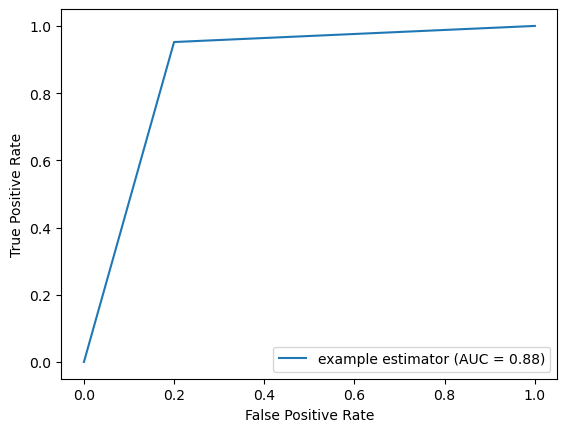

In [37]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [38]:
storeResults('RandomForest',rf_acc,rf_prec,rf_rec,rf_f1)

# GaussianNB

In [39]:
from sklearn.naive_bayes import GaussianNB

clf = GaussianNB()

# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

nb_acc = accuracy_score(y_pred, y_test)
nb_prec = precision_score(y_pred, y_test,average='weighted')
nb_rec = recall_score(y_pred, y_test,average='weighted')
nb_f1 = f1_score(y_pred, y_test,average='weighted')

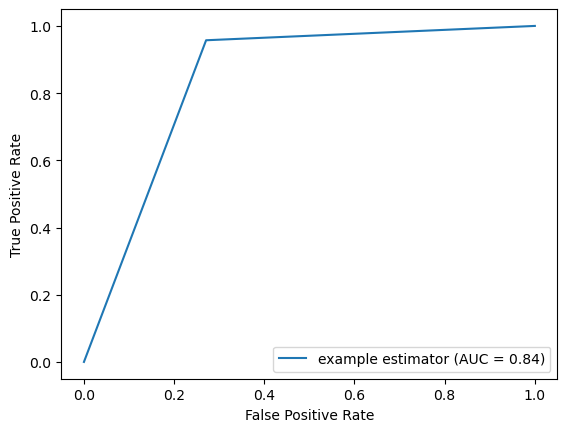

In [40]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [41]:
storeResults('Naive Bayes',nb_acc,nb_prec,nb_rec,nb_f1)

# XGBoost

In [42]:
from xgboost import XGBClassifier

clf = XGBClassifier(n_estimators=5,max_depth=3)
# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

xg_acc = accuracy_score(y_pred, y_test)
xg_prec = precision_score(y_pred, y_test,average='weighted')
xg_rec = recall_score(y_pred, y_test,average='weighted')
xg_f1 = f1_score(y_pred, y_test,average='weighted')

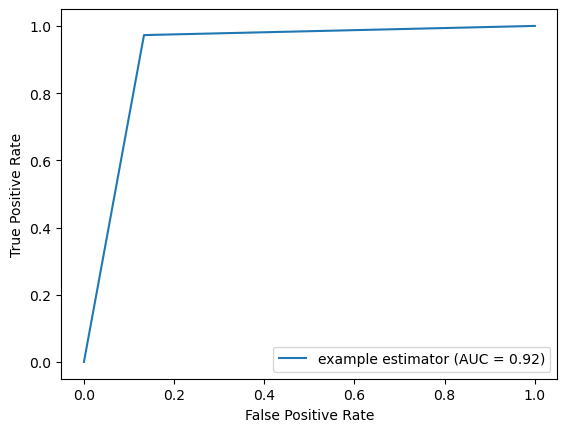

In [43]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [44]:
storeResults('XGBoost',xg_acc,xg_prec,xg_rec,xg_f1)

# Ensemble

In [45]:
from sklearn.ensemble import VotingClassifier

clf1 = RandomForestClassifier(n_estimators=5,max_samples=0.2,max_features=0.3,max_depth=3)
clf2 = GaussianNB()
clf3 = XGBClassifier(n_estimators=5,max_depth=3)

eclf1 = VotingClassifier(estimators=[('RF', clf1), ('NB', clf2), ('XGB', clf3)], voting='soft')
eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

vot_acc = accuracy_score(y_pred, y_test)
vot_prec = precision_score(y_pred, y_test,average='weighted')
vot_rec = recall_score(y_pred, y_test,average='weighted')
vot_f1 = f1_score(y_pred, y_test,average='weighted')

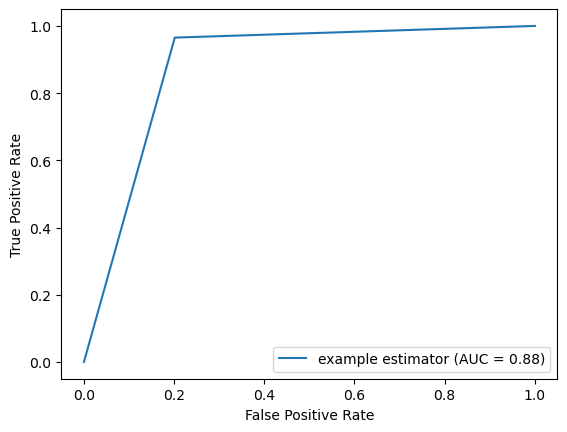

In [46]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [47]:
storeResults('Ensemble',vot_acc,vot_prec,vot_rec,vot_f1)

# Stacking

In [48]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import StackingClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier

clf = BaggingClassifier(RandomForestClassifier(),n_estimators=10, random_state=0)
tree = DecisionTreeClassifier(random_state = 0)

estimators = [('bag', clf),('dt', tree)]

eclf1 = StackingClassifier(estimators=estimators, final_estimator=LGBMClassifier(n_estimators=10))

eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

stac_acc = accuracy_score(y_pred, y_test)
stac_prec = precision_score(y_pred, y_test,average='weighted')
stac_rec = recall_score(y_pred, y_test,average='weighted')
stac_f1 = f1_score(y_pred, y_test,average='weighted')

[LightGBM] [Info] Number of positive: 258482, number of negative: 257186
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002201 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 248
[LightGBM] [Info] Number of data points in the train set: 515668, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501257 -> initscore=0.005027
[LightGBM] [Info] Start training from score 0.005027
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

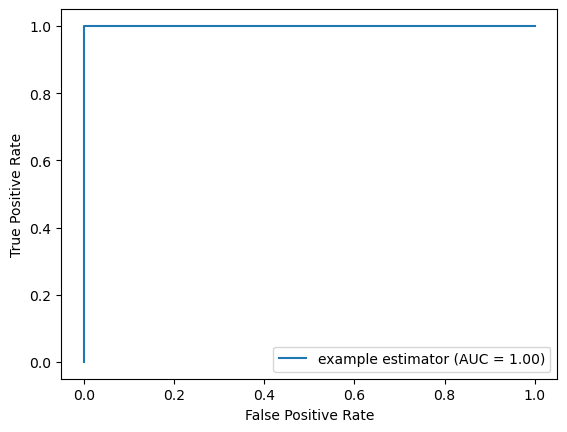

In [49]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [50]:
storeResults('Stacking Classifier',stac_acc,stac_prec,stac_rec,stac_f1)

# Comparison

In [51]:
#creating dataframe
import pandas as pd
import numpy as np
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'f1_score' : f1score,
                        'Recall'   : recall,
                        'Precision': precision,
                                                
                      })

In [52]:
result

,ML Model,Accuracy,f1_score,Recall,Precision
0,RandomForest,0.861,0.862,0.861,0.881
1,Naive Bayes,0.806,0.811,0.806,0.860
2,XGBoost,0.913,0.914,0.913,0.921
3,Ensemble,0.864,0.866,0.864,0.888
4,Stacking Classifier,1.000,1.000,1.000,1.000


# Graph

In [53]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

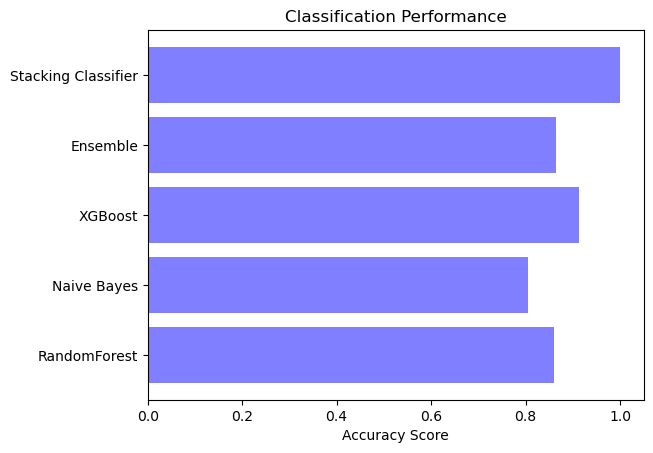

In [54]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

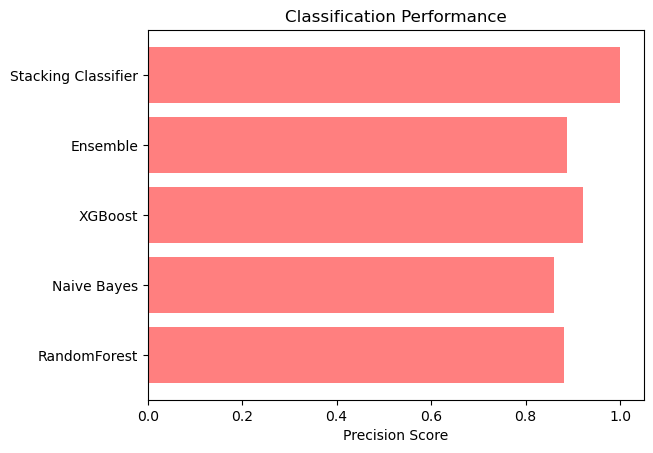

In [55]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

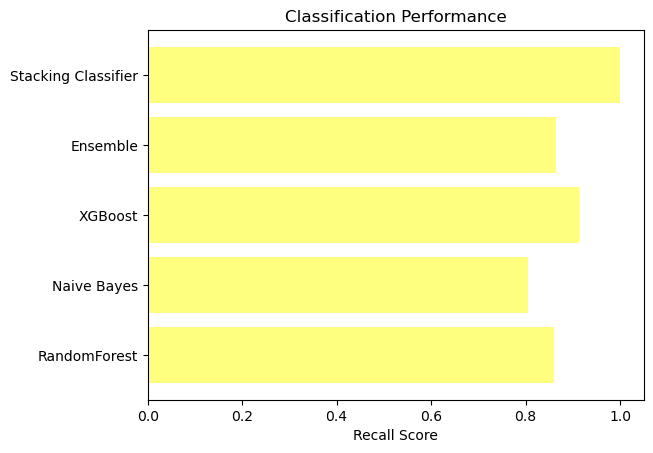

In [56]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1-Score

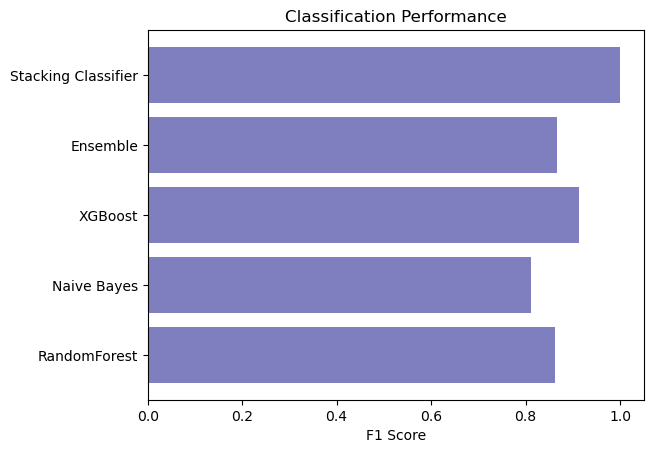

In [57]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# UnderSampling

In [58]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [59]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=0)
X_resampled, y_resampled = rus.fit_resample(X, y)

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.20, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((12009, 10), (12009,), (3003, 10), (3003,))

# RandomForest

In [61]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=5,max_samples=0.2,max_features=0.3,max_depth=3)
# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='weighted')

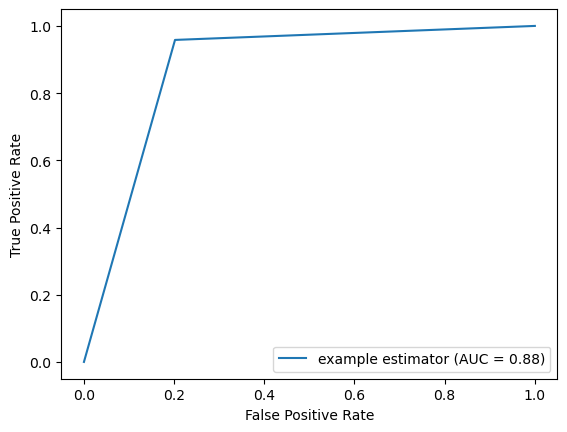

In [62]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [63]:
storeResults('RandomForest',rf_acc,rf_prec,rf_rec,rf_f1)

# GaussianNB

In [64]:
from sklearn.naive_bayes import GaussianNB

clf = GaussianNB()

# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

nb_acc = accuracy_score(y_pred, y_test)
nb_prec = precision_score(y_pred, y_test,average='weighted')
nb_rec = recall_score(y_pred, y_test,average='weighted')
nb_f1 = f1_score(y_pred, y_test,average='weighted')

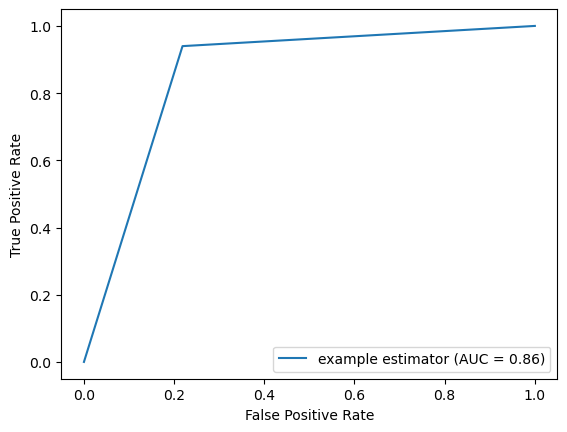

In [65]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [66]:
storeResults('Naive Bayes',nb_acc,nb_prec,nb_rec,nb_f1)

# XGBoost

In [67]:
from xgboost import XGBClassifier

clf = XGBClassifier(n_estimators=5,max_depth=3)
# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

xg_acc = accuracy_score(y_pred, y_test)
xg_prec = precision_score(y_pred, y_test,average='weighted')
xg_rec = recall_score(y_pred, y_test,average='weighted')
xg_f1 = f1_score(y_pred, y_test,average='weighted')

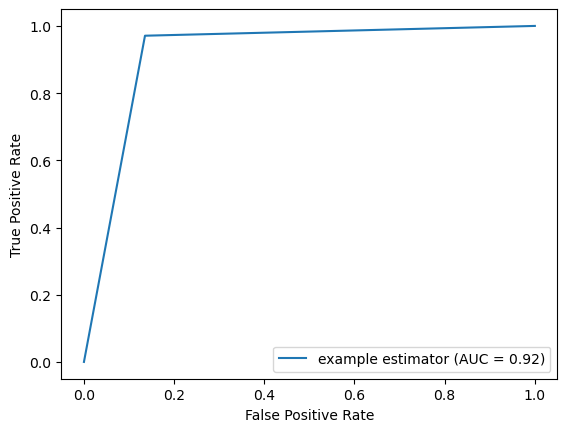

In [68]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [69]:
storeResults('XGBoost',xg_acc,xg_prec,xg_rec,xg_f1)

# Ensemble

In [70]:
clf1 = RandomForestClassifier(n_estimators=5,max_samples=0.2,max_features=0.3,max_depth=3)
clf2 = GaussianNB()
clf3 = XGBClassifier(n_estimators=5,max_depth=3)

eclf1 = VotingClassifier(estimators=[('RF', clf1), ('NB', clf2), ('XGB', clf3)], voting='soft')
eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

vot_acc = accuracy_score(y_pred, y_test)
vot_prec = precision_score(y_pred, y_test,average='weighted')
vot_rec = recall_score(y_pred, y_test,average='weighted')
vot_f1 = f1_score(y_pred, y_test,average='weighted')

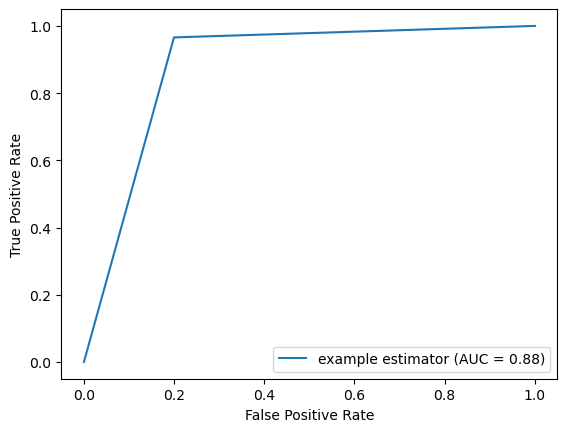

In [71]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [72]:
storeResults('Ensemble',vot_acc,vot_prec,vot_rec,vot_f1)

# Stacking

In [73]:
clf = BaggingClassifier(RandomForestClassifier(),n_estimators=10, random_state=0)
tree = DecisionTreeClassifier(random_state = 0)

estimators = [('bag', clf),('dt', tree)]

eclf1 = StackingClassifier(estimators=estimators, final_estimator=LGBMClassifier(n_estimators=10))

eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

stac_acc = accuracy_score(y_pred, y_test)
stac_prec = precision_score(y_pred, y_test,average='weighted')
stac_rec = recall_score(y_pred, y_test,average='weighted')
stac_f1 = f1_score(y_pred, y_test,average='weighted')

[LightGBM] [Info] Number of positive: 1496, number of negative: 1507
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000158 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 253
[LightGBM] [Info] Number of data points in the train set: 3003, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.498168 -> initscore=-0.007326
[LightGBM] [Info] Start training from score -0.007326


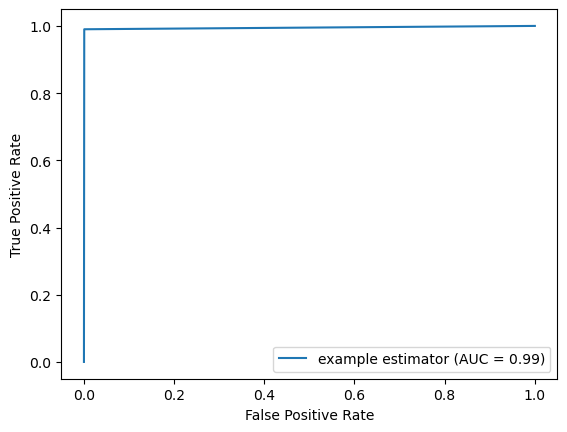

In [74]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [75]:
storeResults('Stacking Classifier',stac_acc,stac_prec,stac_rec,stac_f1)

# Comparison

In [76]:
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'f1_score' : f1score,
                        'Recall'   : recall,
                        'Precision': precision,
                                                
                      })

In [77]:
result

,ML Model,Accuracy,f1_score,Recall,Precision
0,RandomForest,0.861,0.862,0.861,0.884
1,Naive Bayes,0.843,0.845,0.843,0.867
2,XGBoost,0.911,0.911,0.911,0.919
3,Ensemble,0.865,0.866,0.865,0.888
4,Stacking Classifier,0.995,0.995,0.995,0.995


# Graph

In [78]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

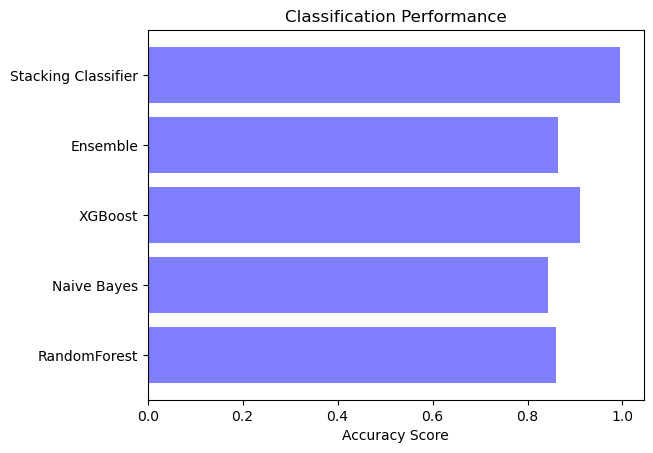

In [79]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

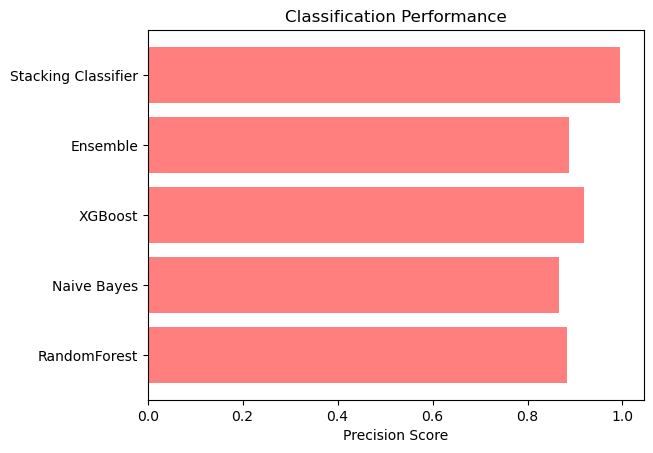

In [80]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

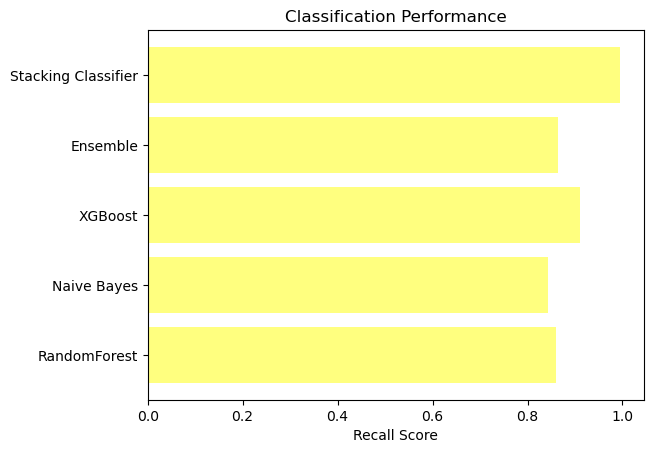

In [81]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1-SCore

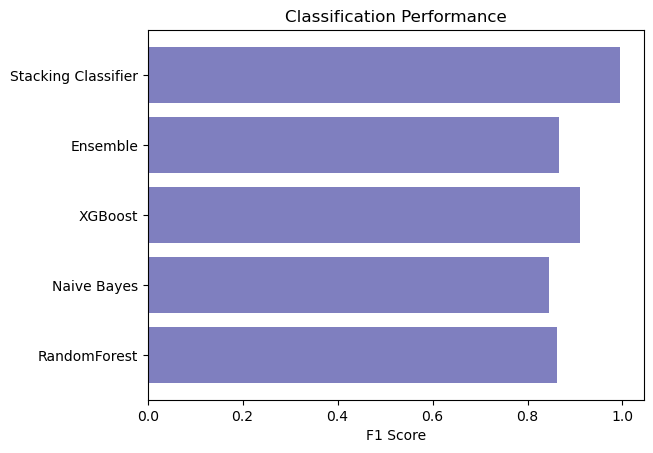

In [82]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# Smote

In [83]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [84]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 42)
X_resampled, y_resampled = sm.fit_resample(X, y)

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.20, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((2062670, 10), (2062670,), (515668, 10), (515668,))

# Random Forest

In [86]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=5,max_samples=0.2,max_features=0.3,max_depth=3)
# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

rf_acc = accuracy_score(y_pred, y_test)
rf_prec = precision_score(y_pred, y_test,average='weighted')
rf_rec = recall_score(y_pred, y_test,average='weighted')
rf_f1 = f1_score(y_pred, y_test,average='weighted')

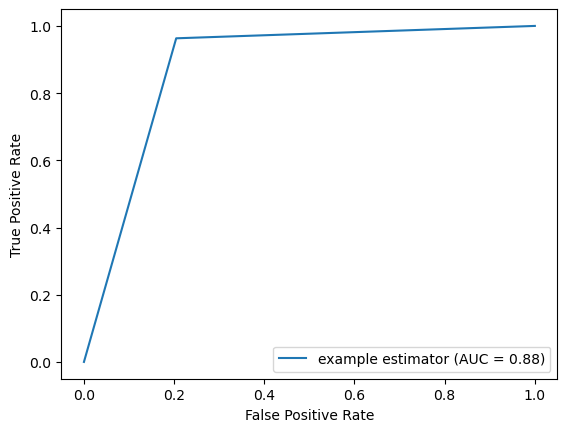

In [87]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [88]:
storeResults('RandomForest',rf_acc,rf_prec,rf_rec,rf_f1)

# GaussianNB

In [89]:
from sklearn.naive_bayes import GaussianNB

clf = GaussianNB()

# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

nb_acc = accuracy_score(y_pred, y_test)
nb_prec = precision_score(y_pred, y_test,average='weighted')
nb_rec = recall_score(y_pred, y_test,average='weighted')
nb_f1 = f1_score(y_pred, y_test,average='weighted')

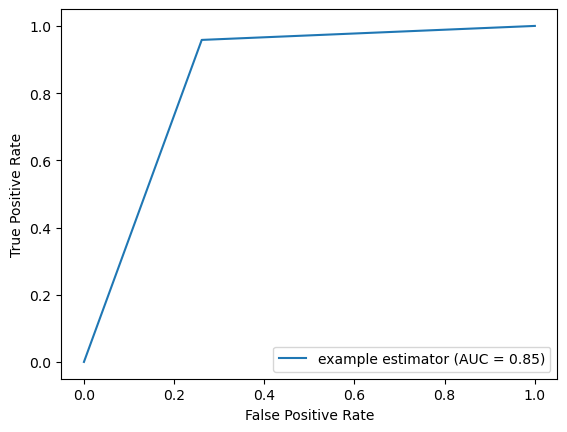

In [90]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [91]:
storeResults('Naive Bayes',nb_acc,nb_prec,nb_rec,nb_f1)

# XGBoost

In [92]:
from xgboost import XGBClassifier

clf = XGBClassifier(n_estimators=5,max_depth=3)
# fit the model 
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

xg_acc = accuracy_score(y_pred, y_test)
xg_prec = precision_score(y_pred, y_test,average='weighted')
xg_rec = recall_score(y_pred, y_test,average='weighted')
xg_f1 = f1_score(y_pred, y_test,average='weighted')

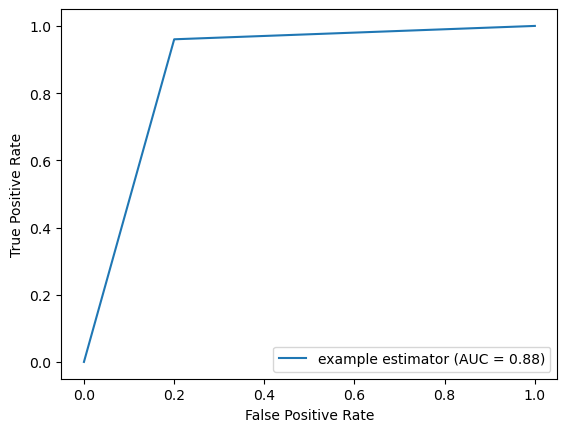

In [93]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [94]:
storeResults('XGBoost',xg_acc,xg_prec,xg_rec,xg_f1)

# Ensemble

In [95]:
clf1 = RandomForestClassifier(n_estimators=5,max_samples=0.2,max_features=0.3,max_depth=3)
clf2 = GaussianNB()
clf3 = XGBClassifier(n_estimators=5,max_depth=3)

eclf1 = VotingClassifier(estimators=[('RF', clf1), ('NB', clf2), ('XGB', clf3)], voting='soft')
eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

vot_acc = accuracy_score(y_pred, y_test)
vot_prec = precision_score(y_pred, y_test,average='weighted')
vot_rec = recall_score(y_pred, y_test,average='weighted')
vot_f1 = f1_score(y_pred, y_test,average='weighted')

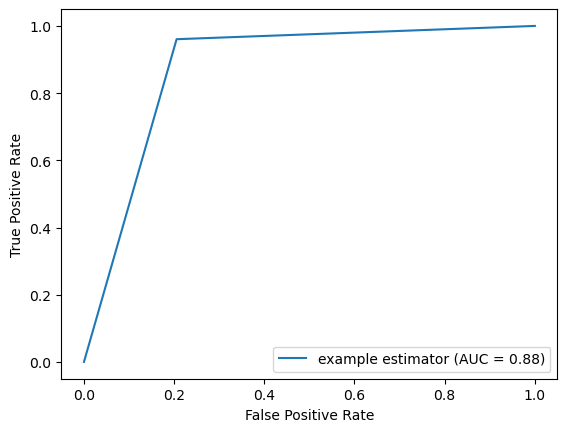

In [96]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [97]:
storeResults('Ensemble',vot_acc,vot_prec,vot_rec,vot_f1)

# Stacking

In [98]:
clf = BaggingClassifier(RandomForestClassifier(),n_estimators=10, random_state=0)
tree = DecisionTreeClassifier(random_state = 0)

estimators = [('bag', clf),('dt', tree)]

eclf1 = StackingClassifier(estimators=estimators, final_estimator=LGBMClassifier(n_estimators=10))

eclf1.fit(X_train, y_train)
y_pred = eclf1.predict(X_test)

stac_acc = accuracy_score(y_pred, y_test)
stac_prec = precision_score(y_pred, y_test,average='weighted')
stac_rec = recall_score(y_pred, y_test,average='weighted')
stac_f1 = f1_score(y_pred, y_test,average='weighted')

[LightGBM] [Info] Number of positive: 258482, number of negative: 257186
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001652 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 237
[LightGBM] [Info] Number of data points in the train set: 515668, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501257 -> initscore=0.005027
[LightGBM] [Info] Start training from score 0.005027


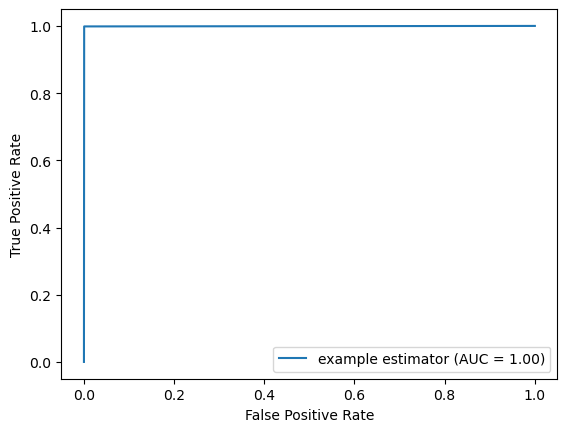

In [99]:
fpr, tpr, thresholds = metrics.roc_curve(y_pred, y_test)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,estimator_name='example estimator')
display.plot()
plt.show()

In [100]:
storeResults('Stacking Classifier',stac_acc,stac_prec,stac_rec,stac_f1)

# Comparison

In [101]:
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'f1_score' : f1score,
                        'Recall'   : recall,
                        'Precision': precision,
                                                
                      })

In [102]:
result

,ML Model,Accuracy,f1_score,Recall,Precision
0,RandomForest,0.861,0.863,0.861,0.885
1,Naive Bayes,0.814,0.819,0.814,0.863
2,XGBoost,0.863,0.865,0.863,0.885
3,Ensemble,0.860,0.861,0.860,0.883
4,Stacking Classifier,0.999,0.999,0.999,0.999


# Modelling

In [103]:
import joblib
filename = 'model_spark.sav'
joblib.dump(eclf1, filename)

['model_spark.sav']

# Graph

In [105]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

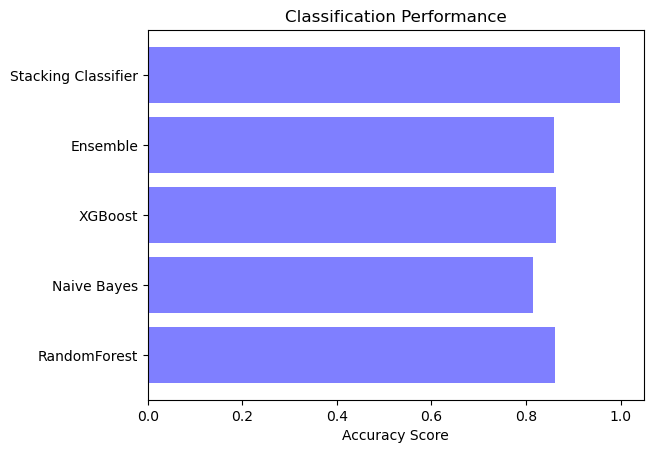

In [106]:
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

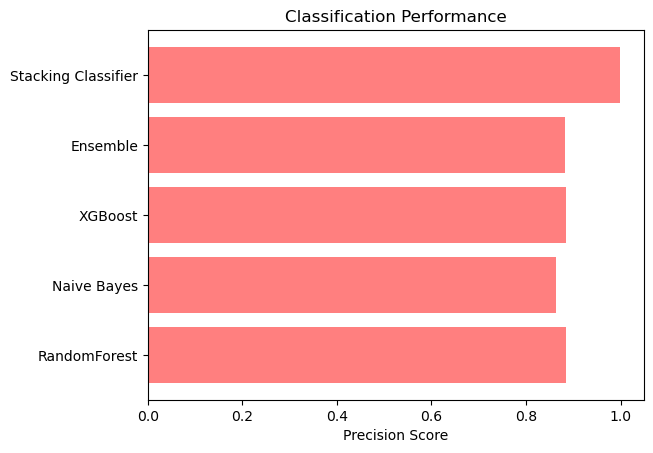

In [107]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

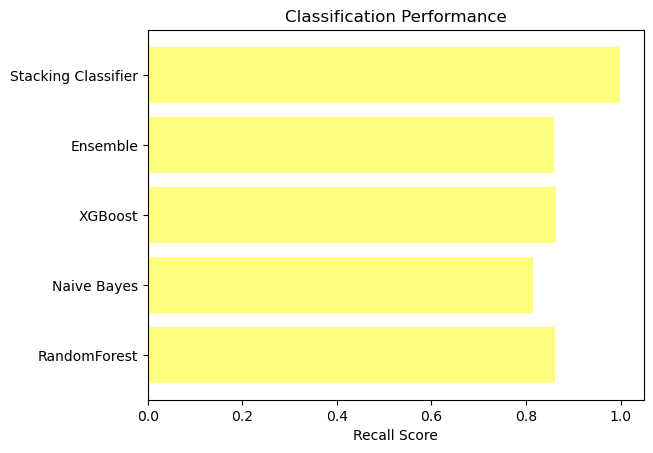

In [108]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

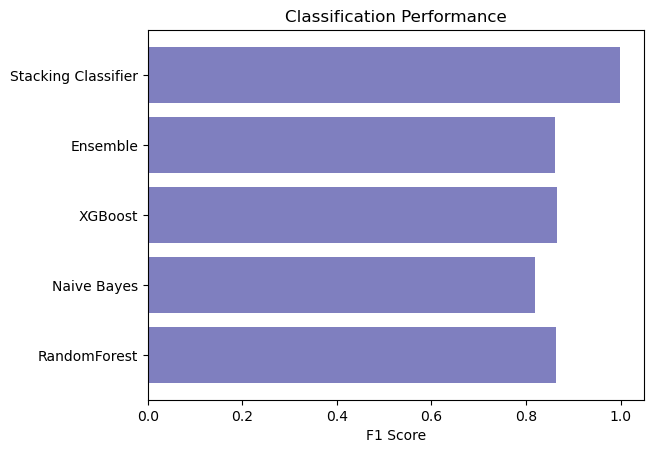

In [109]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()